# 04: OME-Zarr real-data workflow (segmentation to mapping, UV projection)

Reproduces the segmentation-to-mapping and volume-to-UV-space projection steps against a
**real** OME-Zarr (OME-NGFF) dataset, using an **existing precomputed segmentation** rather
than an intensity threshold, and demonstrates the parameterization warm-start across two
consecutive timepoints.

**Scope**: parameterization + projection only — no flow estimation in this notebook (see
`02_flow_computation.ipynb` / `03_end_to_end_timeseries.ipynb` for that, once you have a
projection to feed them). Every stage below is timed, since knowing how long each step
actually takes at the resolution you care about is the point of this notebook, not just
the code shape.

**Two different pyramid levels, on purpose**: `marching_cubes` (surface extraction) runs on
a coarse `label_level` for speed — for this dataset, the segmentation was originally computed
at a coarse level and *upscaled* through the pyramid, so the finer levels carry no extra real
surface information; segmenting at a coarse level costs nothing in accuracy and a lot less
compute. The volume-to-UV projection then runs against the **full-resolution** intensity
level, since that's where the actual signal lives. `Parameterizer.from_ome_zarr` rescales the
segmentation-derived surface points from the label level's voxel grid into the intensity
level's voxel grid automatically (via each level's OME-NGFF `scale`/`translation` metadata) —
without that rescale, mixing levels would silently sample the wrong location in the
intensity volume.

## Data requirements

This notebook needs a real external OME-Zarr (OME-NGFF v0.4) store with:
- A main multiscale image with axes exactly `(t, c, z, y, x)`.
- A `labels/<name>/` sub-group holding a precomputed segmentation (binary or labeled) — set
  `LABEL_NAME` below to match.

It won't run standalone on a fresh clone the way `01_parameterization_workflow.ipynb` does
(that one ships a small bundled synthetic dataset) — real microscopy data at this scale isn't
something to commit to a git repo. Point `SEAMLESS_OME_ZARR_STORE` at your store, or edit
`DEFAULT_STORE` below.

In [ ]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import igl
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from scipy.interpolate import LinearNDInterpolator
from scipy.ndimage import map_coordinates
from skimage.measure import marching_cubes

from seamless import Parameterizer
from seamless.cartography import eval_surface
from seamless.cartography.projection import _orient_outward
from seamless.pipeline import _binarize_segmentation
from seamless.utils.ome_zarr import OMEZarrDataset

DEFAULT_STORE = "../../Position_10.ome.zarr"  # relative default; override via the env var below
STORE = Path(os.environ.get("SEAMLESS_OME_ZARR_STORE", DEFAULT_STORE))

TOPOLOGY = "cylinder"          # closed, roughly spherical embryo surface
LABEL_NAME = "embryo"        # existing precomputed segmentation under labels/<name>/
LABEL_LEVEL = 1              # coarse -- fast marching_cubes, no accuracy loss (see above)
INTENSITY_LEVEL = 0          # full resolution -- what we actually want to project
UV_RES = 512
NUM_TARGET_POINTS = 20_000
T = 15
NUM_CHARTS = 2
timings = {}


class _Timed:
    def __init__(self, name):
        self.name = name

    def __enter__(self):
        self.t0 = time.perf_counter()
        return self

    def __exit__(self, *exc):
        timings[self.name] = time.perf_counter() - self.t0
        print(f"[{self.name}] {timings[self.name]:.2f}s")


def timed(name):
    return _Timed(name)

## Open the store and inspect it

Just parses `.zattrs`/`.zarray` metadata -- no volume data is read yet.

In [78]:
with timed("open dataset"):
    ds = OMEZarrDataset(STORE)

print(f"timepoints: {ds.n_timepoints}, channels: {ds.n_channels}")
print(f"levels: {[(lv.path, lv.shape, lv.voxel_size_um) for lv in ds.levels]}")
print(f"available labels: {ds.label_names}")

[open dataset] 0.00s
timepoints: 132, channels: 1
levels: [('0', (132, 1, 300, 2291, 2303), (1.0, 0.26, 0.26)), ('1', (132, 1, 150, 1145, 1151), (2.0, 0.52, 0.52)), ('2', (132, 1, 150, 572, 575), (2.0, 1.04, 1.04)), ('3', (132, 1, 150, 286, 287), (2.0, 2.08, 2.08)), ('4', (132, 1, 150, 143, 143), (2.0, 4.16, 4.16))]
available labels: ['embryo']


## t = 0: segmentation to mapping

`Parameterizer.from_ome_zarr` reads the `labels/embryo` segmentation at `LABEL_LEVEL`, runs
`marching_cubes` on it, and rescales the resulting surface points into `INTENSITY_LEVEL`'s
voxel grid -- no intensity threshold needed, since we already have a real segmentation.

In [79]:
with timed("t=0 segmentation-to-mapping (label_level={})".format(LABEL_LEVEL)):
    p0 = Parameterizer.from_ome_zarr(
        STORE, TOPOLOGY, t=T, level=INTENSITY_LEVEL,
        label_name=LABEL_NAME, label_level=LABEL_LEVEL,
        num_target_points=NUM_TARGET_POINTS, num_charts=NUM_CHARTS
    )

print(f"t=0 surface points: {p0._full_points.shape[0]}")
print(f"device: {p0.device}")

[t=0 segmentation-to-mapping (label_level=1)] 4.91s
t=0 surface points: 20000
device: cuda


In [ ]:
with timed("t=0 train (cold start)"):
    model0 = p0.train(iterations=1000, verbose=True, lr=1e-3, use_warm_start=False)

uv_map0 = p0.get_uv_map()
print(f"UV map: {uv_map0.shape}")

SyntaxError: keyword argument repeated: verbose (769729652.py, line 2)

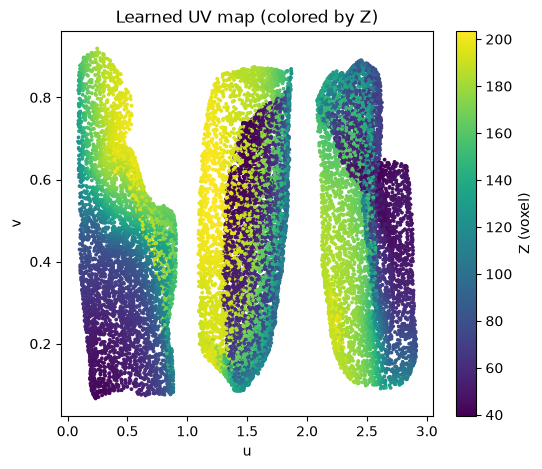

In [96]:
pts = p0.points_voxel.numpy()         # surface points in voxel space
uv_map = p0.get_uv_map()  
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(uv_map[:, 0], uv_map[:, 1], c=pts[:, 0], s=3, cmap='viridis')
ax.set(xlabel='u', ylabel='v', title='Learned UV map (colored by Z)')
fig.colorbar(sc, ax=ax, label='Z (voxel)')
plt.show()

## Visualize the surface and the UV seam in 3D

The 2D UV scatter above shows the flattened chart; this renders the same points back in
their physical 3D positions (µm, using `INTENSITY_LEVEL`'s voxel size) so the seam's actual
location on the embryo surface is visible. The cloud is colored by distance-to-seam in local
UV space (`min(u_local, 1-u_local)`, zero at the cut) with a **sequential** colorscale on
purpose — a cyclic one would visually smooth over exactly the discontinuity we're trying to
show.

Rather than guessing at the seam's location from however densely the *training* point cloud
happens to sample near the boundary, the seam itself is traced directly: query the trained
model's UV→3D map (`eval_surface`) along `u=0` and `u=1` for `v` swept across `[0, 1]` — the
two edges of the UV chart that represent the same physical cut — and draw each as a 3D line.
If the two curves coincide, the cut is well "glued"; if they diverge, that's a real,
visible measure of how well the NuvoMLP's cycle-consistency loss (`three_two_three_loss`/
`two_three_two_loss` in `seamless/cartography/nuvo_losses.py`) has actually converged for
this training run — worth knowing given this notebook's cold-start config uses few
iterations and `phase_b_ratio=0`. Rotate/zoom/pan directly in the notebook (Plotly, not
napari — no separate window).

In [82]:
def plot_uv_seam_3d(param, voxel_size_um, translation, n_seam_samples=400,
                     title="UV seam on surface (physical space)"):
    """Interactive 3D Plotly view of a trained Parameterizer's surface, with the UV
    seam traced directly from the network's UV->3D mapping (not inferred from the
    training point cloud's incidental density near the cut).

    Args:
        param: A trained `Parameterizer` (`.train()` already called).
        voxel_size_um: (z, y, x) microns per voxel for the level `param.points_voxel` is in.
        translation:   (z, y, x) physical offset (µm) for that same level.
        n_seam_samples: Number of points sampled along each chart's seam curve.
    """
    scale = np.asarray(voxel_size_um, dtype=np.float64)
    trans = np.asarray(translation, dtype=np.float64)

    def to_um(pts_voxel):
        return pts_voxel * scale + trans  # (Z, Y, X) order preserved

    pts = param.points_voxel.numpy()
    uv_map = param.get_uv_map()
    chart_ids = param.chart_ids
    pts_um = to_um(pts)

    u_local = uv_map[:, 0] - chart_ids
    d_seam = np.minimum(u_local, 1.0 - u_local)   # 0 at the seam, 0.5 antipodal to it

    # pts_um columns are (Z, Y, X); plot as (X, Y, Z) for a conventional right-handed view
    x, y, z = pts_um[:, 2], pts_um[:, 1], pts_um[:, 0]

    main_trace = go.Scatter3d(
        x=x, y=y, z=z, mode="markers", name="surface (dist-to-seam)",
        marker=dict(
            size=2, color=d_seam, colorscale="Viridis", showscale=True,
            colorbar=dict(title="dist to seam<br>(local u)"),
        ),
    )

    # Trace the seam curve itself: query the trained model at u=0 and u=1 (the two
    # edges of each chart's UV square -- the same physical cut) across the full v
    # range, per chart. This is the ground truth for "where is the seam", independent
    # of how the training point cloud happened to sample near it.
    model = param.get_model()
    pts_mean = param.pts_mean.numpy()
    pts_std = float(param.pts_std)
    v_line = np.linspace(0.0, 1.0, n_seam_samples, dtype=np.float32)
    edge_style = {0.0: dict(color="red", dash=None), 1.0: dict(color="orange", dash="dash")}

    seam_traces = []
    for chart in np.unique(chart_ids):
        edge_um = {}
        for u_edge in edge_style:
            uv_edge = np.stack([np.full_like(v_line, u_edge), v_line], axis=1)
            xyz_norm_edge = eval_surface(model, uv_edge, chart_idx=int(chart), device=param.device)
            edge_um[u_edge] = to_um(xyz_norm_edge * pts_std + pts_mean)

        # Since u=0 and u=1 are the *same* physical cut, a perfectly cycle-consistent
        # model would place them at identical 3D positions -- any gap is a direct,
        # measurable sign of how well the NuvoMLP's cut is actually "glued".
        gap = np.linalg.norm(edge_um[0.0] - edge_um[1.0], axis=1)
        print(f"[{title}] chart {chart}: NuVo seam gap between u=0/u=1 curves -- "
              f"mean {gap.mean():.1f} um, max {gap.max():.1f} um")

        for u_edge, style in edge_style.items():
            pts_um_edge = edge_um[u_edge]
            xs, ys, zs = pts_um_edge[:, 2], pts_um_edge[:, 1], pts_um_edge[:, 0]
            seam_traces.append(go.Scatter3d(
                x=xs, y=ys, z=zs, mode="lines",
                line=dict(color=style["color"], width=6, dash=style["dash"]),
                name=f"seam curve (chart {chart}, u={u_edge:g})",
            ))

    fig = go.Figure(data=[main_trace, *seam_traces])
    fig.update_layout(
        title=title,
        showlegend=True,
        scene=dict(
            aspectmode="data",
            xaxis_title="X (µm)", yaxis_title="Y (µm)", zaxis_title="Z (µm)",
            camera=dict(eye=dict(x=1.6, y=1.6, z=1.0)),
        ),
        width=800, height=650,
    )
    fig.show()
    return fig


level0 = ds.get_level(INTENSITY_LEVEL)
plot_uv_seam_3d(
    p0, voxel_size_um=level0.voxel_size_um, translation=level0.translation[-3:],
    title="t=0: UV seam on surface (physical space)",
)

[t=0: UV seam on surface (physical space)] chart 0: NuVo seam gap between u=0/u=1 curves -- mean 158.5 um, max 186.2 um
[t=0: UV seam on surface (physical space)] chart 1: NuVo seam gap between u=0/u=1 curves -- mean 157.9 um, max 186.4 um
[t=0: UV seam on surface (physical space)] chart 2: NuVo seam gap between u=0/u=1 curves -- mean 130.3 um, max 144.9 um


## Classical comparison: LSCM (Least-Squares Conformal Maps)

How would a classical mesh-based tool place a seam on this same surface? [Blender tissue
cartography](https://www.biorxiv.org/content/10.1101/2025.02.04.636523v1.full) — a recent
Blender add-on for exactly this kind of surface flattening — offers, among other options,
**Least-Squares Conformal Maps** (LSCM, Lévy et al. 2002) as its "Conformal" unwrap method.
`libigl` (`igl.lscm`) implements the same algorithm — and is already a declared dependency of
this project (`pyproject.toml`) that, until now, nothing in `seamless` actually imported.

The comparison isn't quite apples-to-apples, and that's the point:

- **NuvoMLP** learns one continuous 3D→UV *and* UV→3D neural mapping per chart. The seam is
  wherever the network's periodic `u` convention happens to wrap — there's no explicit "cut,"
  so nothing guarantees the two sides actually agree in 3D (as just measured above).
- **LSCM** needs an actual mesh (vertices *and* faces — the `Parameterizer` discards face
  connectivity after marching cubes, so the mesh is re-extracted here) and, since the embryo
  segmentation is a closed, genus-0 surface with no natural boundary, it must be **cut open**
  before it can be flattened at all — this is exactly the "manual seam cutting" step Blender
  tissue cartography's graphical workflow requires. Here the cut is found automatically: the
  shortest mesh-edge path (Dijkstra) between the two extreme points along the surface's
  principal axis (playing the same "poles" role as NuVo's cylinder `v=0`/`v=1`), opened via
  `igl.cut_mesh`, then flattened with `igl.lscm` pinned at those two poles.

Because it's a literal topological cut of *one* mesh — not two independently-learned inverse
maps — the two sides of an LSCM cut are, by construction, at the exact same 3D position: the
gap NuVo showed above is structurally impossible here. What LSCM can't avoid instead is
**distortion**: conformal maps preserve angles exactly by letting area stretch freely, so
regions of the embryo with high curvature will show up compressed or stretched in UV space —
visible below as sharp changes in "distance to seam" color density.

In [48]:
with timed("LSCM: re-extract mesh with faces + decimate"):
    label_ds = ds.label_dataset(LABEL_NAME)
    label_level_meta = label_ds.get_level(LABEL_LEVEL)
    segmentation = label_ds.read_volume(T, LABEL_LEVEL)
    binary = _binarize_segmentation(segmentation, label=None)
    verts_lscm, faces_lscm, _, _ = marching_cubes(binary, level=0.5, step_size=1)
    # Convert straight to physical microns (NOT `INTENSITY_LEVEL`'s voxel-index grid --
    # that's still anisotropic and would leave the mesh looking squashed in Z, since
    # this dataset's voxels are ~3.8x taller in Z than in X/Y). Everything downstream
    # (PCA axis, Dijkstra path, LSCM solve) runs in these physical units so the result
    # is a geometrically correct, isotropic mesh -- and matches the NuVo plot's units.
    verts_lscm = (verts_lscm * np.asarray(label_level_meta.voxel_size_um)
                  + np.asarray(label_level_meta.translation[-3:]))

    # Decimate to roughly the same point-cloud size NuVo trains on (20k), for a fair
    # resolution comparison and a tractable LSCM linear solve.
    V_lscm, F_lscm, _, _ = igl.decimate(
        verts_lscm.astype(np.float64), faces_lscm.astype(np.int32), max_m=2 * NUM_TARGET_POINTS)

print(f"decimated mesh: {V_lscm.shape[0]} vertices, {F_lscm.shape[0]} faces "
      f"(closed: {len(igl.boundary_loop(F_lscm)) == 0})")

with timed("LSCM: find seam path (PCA poles + Dijkstra shortest path)"):
    # PCA-align, same convention as NuVo's analytic cylinder warm-start: the largest-
    # variance axis plays the role of "height" (v), and its two extremes are the poles.
    centered = V_lscm - V_lscm.mean(axis=0)
    _, principal_axes = np.linalg.eigh(centered.T @ centered)
    axis = principal_axes[:, -1]
    proj = centered @ axis
    pole_a, pole_b = int(np.argmin(proj)), int(np.argmax(proj))

    edges = igl.edges(F_lscm)
    edge_len = np.linalg.norm(V_lscm[edges[:, 0]] - V_lscm[edges[:, 1]], axis=1)
    n_v = V_lscm.shape[0]
    graph = csr_matrix(
        (np.concatenate([edge_len, edge_len]),
         (np.concatenate([edges[:, 0], edges[:, 1]]), np.concatenate([edges[:, 1], edges[:, 0]]))),
        shape=(n_v, n_v),
    )
    _, predecessors = dijkstra(graph, directed=False, indices=pole_a, return_predecessors=True)
    seam_path = [pole_b]
    while seam_path[-1] != pole_a:
        seam_path.append(predecessors[seam_path[-1]])
    seam_path = np.array(seam_path[::-1])

print(f"seam path: {len(seam_path)} vertices from pole {pole_a} to pole {pole_b}")

with timed("LSCM: cut mesh open + solve"):
    # Mark the seam path's edges for cutting (per-face boolean, libigl's edge-i-of-face
    # convention: edge i connects face[i] to face[(i+1) % 3]).
    path_edges = {(int(a), int(b)) for a, b in zip(seam_path[:-1], seam_path[1:])}
    path_edges |= {(b, a) for a, b in path_edges}
    cut_flags = np.zeros((F_lscm.shape[0], 3), dtype=bool)
    for ei in range(3):
        a, b = F_lscm[:, ei], F_lscm[:, (ei + 1) % 3]
        cut_flags[:, ei] = [(int(x), int(y)) in path_edges for x, y in zip(a, b)]

    V_cut, F_cut, vertex_map = igl.cut_mesh(V_lscm.astype(np.float64), F_lscm.astype(np.int64), cut_flags)

    # The two poles are cut-path *endpoints*, so (unlike interior path vertices) each
    # keeps exactly one copy in the cut mesh -- pin those as LSCM's 2 fixed points,
    # playing the same v=0 / v=1 role NuVo's poles do.
    pole_a_cut = int(np.where(vertex_map == pole_a)[0][0])
    pole_b_cut = int(np.where(vertex_map == pole_b)[0][0])
    uv_lscm, _ = igl.lscm(
        V_cut, F_cut,
        b=np.array([pole_a_cut, pole_b_cut], dtype=np.int64),
        bc=np.array([[0.0, 0.0], [0.0, 1.0]]),
    )

with timed("LSCM: geodesic distance-to-seam"):
    # Exact analogue of NuVo's d_seam plot, but a real mesh-geodesic distance to the
    # actual cut path rather than a UV-space formula.
    dist_to_seam_lscm = dijkstra(graph, directed=False, indices=seam_path, min_only=True)

print(f"LSCM UV range: u=[{uv_lscm[:,0].min():.2f},{uv_lscm[:,0].max():.2f}]  "
      f"v=[{uv_lscm[:,1].min():.2f},{uv_lscm[:,1].max():.2f}]")
print("LSCM seam gap between the cut's two sides: 0.0 um (exact, by construction -- "
      "see plot below vs. the NuVo gap measured above)")

[LSCM: re-extract mesh with faces + decimate] 8.50s
decimated mesh: 20002 vertices, 40000 faces (closed: True)
[LSCM: find seam path (PCA poles + Dijkstra shortest path)] 0.01s
seam path: 127 vertices from pole 14531 to pole 6055
[LSCM: cut mesh open + solve] 0.26s
[LSCM: geodesic distance-to-seam] 0.00s
LSCM UV range: u=[-0.76,0.71]  v=[-0.13,1.14]
LSCM seam gap between the cut's two sides: 0.0 um (exact, by construction -- see plot below vs. the NuVo gap measured above)


In [49]:
def plot_lscm_seam_3d(V, seam_path, dist_to_seam, title="LSCM seam on surface (physical space)"):
    """Interactive 3D Plotly view of a mesh flattened via LSCM, with the seam curve
    (the mesh cut path) drawn directly from the original mesh coordinates -- both
    sides of the cut share these same coordinates by construction, unlike NuVo's
    independently-learned u=0/u=1 curves.

    Args:
        V: (N, 3) mesh vertex positions, physical units, (Z, Y, X) column order.
        seam_path: (M,) vertex indices into V along the cut path, pole to pole.
        dist_to_seam: (N,) geodesic distance from each vertex to the seam path.
    """
    x, y, z = V[:, 2], V[:, 1], V[:, 0]
    main_trace = go.Scatter3d(
        x=x, y=y, z=z, mode="markers", name="surface (geodesic dist-to-seam)",
        marker=dict(
            size=2, color=dist_to_seam, colorscale="Viridis", showscale=True,
            colorbar=dict(title="geodesic dist<br>to seam (µm)"),
        ),
    )
    seam_xyz = V[seam_path]
    sx, sy, sz = seam_xyz[:, 2], seam_xyz[:, 1], seam_xyz[:, 0]
    seam_trace = go.Scatter3d(
        x=sx, y=sy, z=sz, mode="lines", line=dict(color="red", width=6),
        name="seam curve (LSCM cut, exact -- both sides coincide)",
    )

    fig = go.Figure(data=[main_trace, seam_trace])
    fig.update_layout(
        title=title,
        showlegend=True,
        scene=dict(
            aspectmode="data",
            xaxis_title="X (µm)", yaxis_title="Y (µm)", zaxis_title="Z (µm)",
            camera=dict(eye=dict(x=1.6, y=1.6, z=1.0)),
        ),
        width=800, height=650,
    )
    fig.show()
    return fig


plot_lscm_seam_3d(
    V_lscm, seam_path, dist_to_seam_lscm,
    title="t=0: LSCM seam on surface (physical space) -- compare to the NuVo plot above",
)

## Project the level-0 intensity volume to UV space

This is the full-resolution step -- reads one timepoint's raw intensity volume at
`INTENSITY_LEVEL` (level 0: ~3.2GB for this dataset, uint16) and samples it along the
learned surface normals to build the UV-space projection.

In [83]:
with timed("t=0 read level-0 intensity volume"):
    vol0 = ds.read_volume(t=T, level=INTENSITY_LEVEL)

print(f"vol0: shape={vol0.shape}, dtype={vol0.dtype}, {vol0.nbytes / 1e9:.2f} GB")

with timed("t=0 project_to_uv_along_normals (level 0)"):
    multilayer0, xyz_vox0, xyz_norm0 = p0.project_to_uv_along_normals(
        vol0, offsets =  np.linspace(5, -20, 30), uv_res=UV_RES, return_maps=True)

max_proj0 = multilayer0.max(axis=0)
print(f"multilayer: {multilayer0.shape}  max_projection: {max_proj0.shape}")

# NOTE: vol0 is kept alive here (not deleted) -- the LSCM projection comparison below
# reuses it before it's finally freed at the end of that section.

# fig, ax = plt.subplots(figsize=(6, 6))
# ax.imshow(max_proj0, cmap="gray")
# ax.set_title("t=0 max projection (level 0)")
# ax.axis("off")
# plt.show()

[t=0 read level-0 intensity volume] 7.12s
vol0: shape=(300, 2291, 2303), dtype=uint16, 3.17 GB
[t=0 project_to_uv_along_normals (level 0)] 4.80s


AttributeError: 'list' object has no attribute 'max'

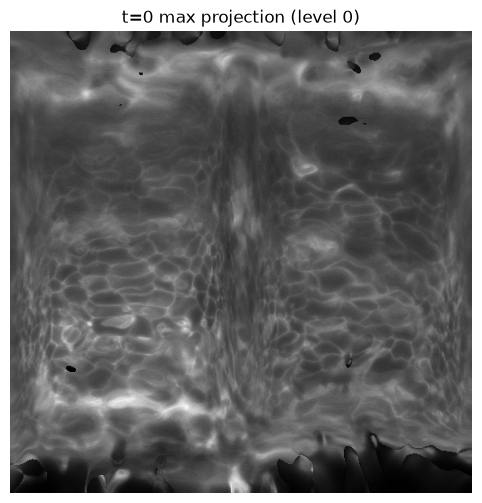

In [51]:

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(multilayer0[25], cmap="gray")
ax.set_title("t=0 max projection (level 0)")
ax.axis("off")
plt.show()

## Project the same volume through the LSCM map, and compare images

Same idea as NuVo's projection above, but through the LSCM UV parameterization computed
earlier (`uv_lscm`, `V_cut`/`F_cut`): interpolate a 3D position *and* surface normal for
every pixel of a regular UV grid (`scipy.interpolate.LinearNDInterpolator` over the mesh's
per-vertex positions and `igl.per_vertex_normals`), sample `vol0` at several offsets along
that normal, and max-project — the same recipe `Parameterizer.project_to_uv_along_normals`
uses, just built from the classical mesh instead of the trained network. Grid points outside
the LSCM UV domain's convex hull come back `NaN` (matching this codebase's existing
`use_hull_mask` convention for the same "don't extrapolate past the surface" reason) and are
left blank in the image.

[LSCM: build UV -> (position, normal) interpolator] 0.17s
[LSCM: project level-0 intensity volume to UV space] 1.46s


/tmp/ipykernel_2755086/1032180519.py:29: RuntimeWarning: All-NaN slice encountered
  max_proj_lscm = np.nanmax(multilayer_lscm, axis=0)


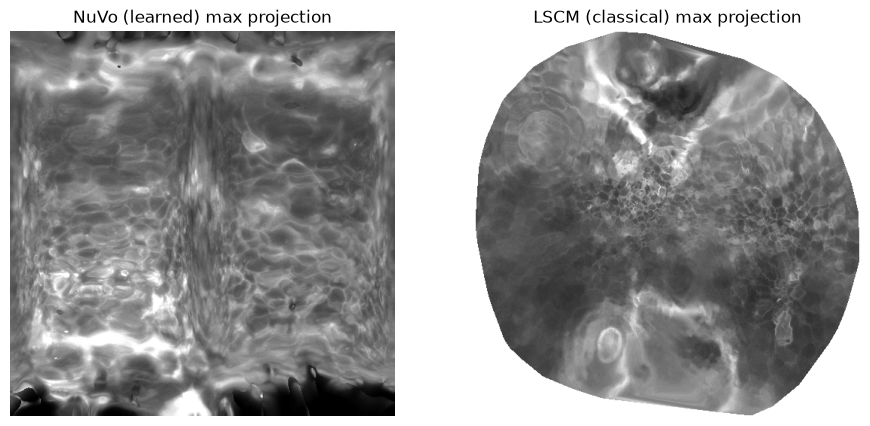

In [63]:
with timed("LSCM: build UV -> (position, normal) interpolator"):
    normals_cut = igl.per_vertex_normals(V_cut, F_cut)
    normals_cut = _orient_outward(normals_cut, V_cut, V_cut, topology=TOPOLOGY)
    uv_to_xyzn = LinearNDInterpolator(uv_lscm, np.hstack([V_cut, normals_cut]))

with timed("LSCM: project level-0 intensity volume to UV space"):
    u_lin = np.linspace(uv_lscm[:, 0].min(), uv_lscm[:, 0].max(), UV_RES)
    v_lin = np.linspace(uv_lscm[:, 1].min(), uv_lscm[:, 1].max(), UV_RES)
    uu, vv = np.meshgrid(u_lin, v_lin, indexing="xy")
    grid = uv_to_xyzn(np.stack([uu.ravel(), vv.ravel()], axis=1))
    xyz_grid_um, normal_grid = grid[:, :3], grid[:, 3:]
    normal_grid = normal_grid / (np.linalg.norm(normal_grid, axis=1, keepdims=True) + 1e-8)

    valid = ~np.isnan(xyz_grid_um).any(axis=1)
    offsets_um = np.linspace(5.0, -20.0, 30)  # physical microns -- same magnitude/order as NuVo's own offsets above
    layers_lscm = []
    for offset in offsets_um:
        sample_um = xyz_grid_um[valid] + offset * normal_grid[valid]
        sample_vox = ((sample_um - np.asarray(level0.translation[-3:]))
                      / np.asarray(level0.voxel_size_um))
        layer = np.full(UV_RES * UV_RES, np.nan, dtype=np.float32)
        layer[valid] = map_coordinates(
            vol0, [sample_vox[:, 0], sample_vox[:, 1], sample_vox[:, 2]],
            order=1, mode="constant", cval=np.nan, output=np.float32,
        )
        layers_lscm.append(layer.reshape(UV_RES, UV_RES))

    multilayer_lscm = np.stack(layers_lscm)
    max_proj_lscm = np.nanmax(multilayer_lscm, axis=0)

# del vol0  # done with the dense level-0 array for this timepoint

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
vmin, vmax = np.nanpercentile(max_proj0, 1), np.nanpercentile(max_proj0, 99)
axes[0].imshow(max_proj0, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("NuVo (learned) max projection")
axes[1].imshow(multilayer_lscm[21], cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("LSCM (classical) max projection")
for a in axes:
    a.axis("off")
plt.show()

## t = 1: time-series warm-start

Reuse `t=0`'s trained NuvoMLP as the starting point (`base_model=`) instead of training from
scratch -- the same warm-start trick `01_parameterization_workflow.ipynb` demonstrates on
synthetic data, now timed against the real dataset.

In [ ]:
with timed("t=1 segmentation-to-mapping (label_level={})".format(LABEL_LEVEL)):
    p1 = Parameterizer.from_ome_zarr(
        STORE, TOPOLOGY, t=T+1, level=INTENSITY_LEVEL,
        label_name=LABEL_NAME, label_level=LABEL_LEVEL,
        num_target_points=NUM_TARGET_POINTS,
    )

print(f"t=1 surface points: {p1._full_points.shape[0]}")

with timed("t=1 train (warm-start from t=0)"):
    model1 = p1.train(base_model=p0.get_model())

speedup = timings["t=0 train (cold start)"] / timings["t=1 train (warm-start from t=0)"]
print(f"warm-start speedup vs. t=0 cold start: {speedup:.1f}x")

[t=1 segmentation-to-mapping (label_level=1)] 4.87s
t=1 surface points: 20000
[t=1 train (warm-start from t=0)] 2.59s
warm-start speedup vs. t=0 cold start: 3.0x


## t = 1: check the seam is stable after warm-start

Same 3D seam trace for the warm-started timepoint. Since `p1.train(base_model=p0.get_model())`
starts from `t=0`'s trained weights, the traced `u=0`/`u=1` curves should land in essentially
the same place on the surface as t=0's — a sanity check that warm-starting isn't letting the
cut drift or flip across the timeseries.

In [ ]:
plot_uv_seam_3d(
    p1, voxel_size_um=level0.voxel_size_um, translation=level0.translation[-3:],
    title="t=1: UV seam on surface (physical space, warm-started)",
)

[t=1: UV seam on surface (physical space, warm-started)] chart 0: NuVo seam gap between u=0/u=1 curves -- mean 49.9 um, max 122.6 um


[t=1 read level-0 intensity volume] 9.09s
[t=1 project_to_uv_along_normals (level 0)] 1.61s


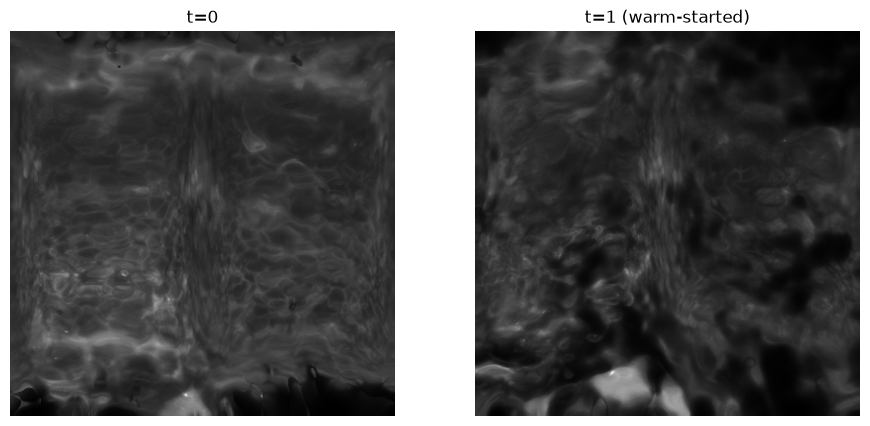

In [ ]:
with timed("t=1 read level-0 intensity volume"):
    vol1 = ds.read_volume(T+1, level=INTENSITY_LEVEL)

with timed("t=1 project_to_uv_along_normals (level 0)"):
    multilayer1, xyz_vox1, xyz_norm1 = p1.project_to_uv_along_normals(
        vol1, uv_res=UV_RES, return_maps=True)

max_proj1 = multilayer1.max(axis=0)
del vol1

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(max_proj0, cmap="gray")
axes[0].set_title("t=0")
axes[1].imshow(max_proj1, cmap="gray")
axes[1].set_title("t=1 (warm-started)")
for a in axes:
    a.axis("off")
plt.show()

## Timing summary

Everything measured above, in one place -- this is the concrete answer to "how long does
level-0 processing actually take" for this dataset on this machine.

In [ ]:
width = max(len(k) for k in timings)
for k, v in timings.items():
    print(f"{k:<{width}}  {v:8.2f}s")

open dataset                                                   0.00s
t=0 segmentation-to-mapping (label_level=1)                    4.87s
t=0 train (cold start)                                         7.75s
LSCM: re-extract mesh with faces + decimate                    8.77s
LSCM: find seam path (PCA poles + Dijkstra shortest path)      0.01s
LSCM: cut mesh open + solve                                    0.26s
LSCM: geodesic distance-to-seam                                0.00s
t=0 read level-0 intensity volume                              7.25s
t=0 project_to_uv_along_normals (level 0)                      3.07s
LSCM: build UV -> (position, normal) interpolator              0.09s
LSCM: project level-0 intensity volume to UV space             0.69s
t=1 segmentation-to-mapping (label_level=1)                    4.87s
t=1 train (warm-start from t=0)                                2.59s
t=1 read level-0 intensity volume                              9.09s
t=1 project_to_uv_along_normals (l

## Notes

- Segmentation (`marching_cubes`) runs at `LABEL_LEVEL` and is fast; the level-0 intensity
  read and projection are the steps that actually scale with the dataset's real resolution.
- This notebook deliberately does not touch `FlowEstimator`/`3d_native` flow: that path needs
  two adjacent timepoints' *intensity* volumes resident as dense float32 tensors
  simultaneously (~4x the raw per-voxel bytes from dtype widening), which at level 0 for this
  dataset does not fit on a small GPU -- pick a coarser `INTENSITY_LEVEL` for that step, or
  budget accordingly, before running it.
- `SeamlessPipeline.from_ome_zarr` does not yet support `label_level != level` (it raises
  `NotImplementedError` rather than silently mis-projecting) -- this notebook uses
  `Parameterizer.from_ome_zarr` directly, which does support it, for exactly that reason.